In [1]:
import pandas as pd
from pandas import DataFrame
from pathlib import Path
import datetime
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, accuracy_score, confusion_matrix
from sklearn import metrics
import matplotlib.pyplot as plt
from matplotlib import pyplot


import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.utils.testing import ignore_warnings
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore')
 



/Users/ericmerdian/opt/anaconda3/lib/python3.7/site-packages/sklearn/utils/deprecation.py:144: FutureWarning: The sklearn.utils.testing module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.utils. Anything that cannot be imported from sklearn.utils is now part of the private API.
  warnings.warn(message, FutureWarning)


In [2]:
#import file
train = pd.read_csv('/Users/ericmerdian/Desktop/Desktop/A_Summer_Research/AllTeams/training.csv')
test = pd.read_csv('/Users/ericmerdian/Desktop/Desktop/A_Summer_Research/AllTeams/testing.csv')

# #time column is not needed
# df = df.drop('Time',1)

# print(df['Possession'].isna().sum())
# #there are 1075 null values for possession

# #drop rows where possession is null
# df = df[df['Possession'].notna()]


# df['GameDatetime'] = pd.to_datetime(df['GameDate'])
# df = df.drop('GameDate',1)

#home team score and point differential
                        
train.head()

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play
0,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.5,Win,0,0,0,1,NaN,NaN,NaN,NaN,2395,5,"FOUL by NOTLEY,CHANDLER"
1,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.5,Win,0,0,0,1,NaN,NaN,NaN,NaN,2380,20,"TURNOVER by JOHNSON,BRYSON"
2,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.5,Win,2,0,-2,1,1.0,NaN,1.0,NaN,2377,23,"GOOD JUMPER by NOTLEY,CHANDLER"
3,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.5,Win,2,0,-2,1,1.0,NaN,1.0,NaN,2377,23,"ASSIST by MOORE,AUSTIN"
4,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.5,Win,2,0,-2,1,1.0,NaN,0.5,NaN,2365,35,"MISS JUMPER by BARNES,SKYLER"


In [3]:
test

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play
0,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,NaN,NaN,0.000,0.000,2372,28,"MISS 3PTR by GONDA,MATT"
1,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,NaN,NaN,0.000,0.000,2372,28,"REBOUND DEF by BRYAN,WILLIAM"
2,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2361,39,"MISS 3PTR by SPRAGG,BAILEY"
3,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2361,39,"REBOUND DEF by ALLISON,ZACHARY"
4,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.50,Win,0,0,0.0,1,0.000,0.000,0.000,0.000,2349,51,"MISS 3PTR by BAK,CALVIN"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85407,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,79,15.0,2,0.458,0.375,0.514,0.436,51,2349,"MISS 3PTR by STANLEY,SETH"
85408,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,79,15.0,2,0.458,0.375,0.514,0.436,51,2349,"REBOUND DEF by LEE,MATT"
85409,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,82,18.0,2,0.458,0.375,0.518,0.446,22,2378,"GOOD 3PTR by CARLETELLO,EMILY"
85410,19_02_22_4_27,Hendrix,Sewanee,0.4,0.76,Win,64,82,18.0,2,0.452,0.364,0.514,0.439,16,2384,"MISS 3PTR by CALAMESE,MICHAEL"


In [4]:
test[test['GameID'] ==  '19_01_27_2_20']

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play
9161,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,1.000,NaN,2382,18,"GOOD LAYUP by STEWART,CHRISTIAN(in the paint)"
9162,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,1.000,NaN,2382,18,"ASSIST by SPENCE,BEN"
9163,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,0.500,NaN,2350,50,"MISS JUMPER by BATES,JACOB"
9164,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,0.500,NaN,2350,50,"REBOUND DEF by STEWART,CHRISTIAN"
9165,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,2,0,-2.0,1,1.000,NaN,0.500,NaN,2340,60,"FOUL by STEWART,CHRISTIAN"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9634,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,71,17.0,2,0.467,0.269,0.481,0.300,36,2364,"MISS 3PTR by WILLIAMS,JALEN"
9635,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,71,17.0,2,0.467,0.269,0.481,0.300,36,2364,"REBOUND OFF by WILLIAMS,JALEN"
9636,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,73,19.0,2,0.467,0.269,0.485,0.300,30,2370,"GOOD LAYUP by WILLIAMS,JALEN(in the paint)"
9637,19_01_27_2_20,Birmingham-Southern,Centre,0.556,0.842,Win,54,73,19.0,2,0.459,0.259,0.482,0.294,20,2380,"MISS 3PTR by ALLISON,ZACHARY"


In [5]:

## one-hot encode

#add win and loss column
df_add1 = pd.get_dummies(train.Outcome, prefix = 'Outcome',drop_first = True)

train = pd.concat([train,df_add1], axis=1)
test = pd.concat([test,df_add1], axis=1)




In [6]:
train.groupby(['GameID', 'Outcome_Win']).ngroups

162

In [7]:
game_outcome = train.groupby(["GameID", "Outcome_Win"]).size().reset_index()

In [8]:
game_outcome

,GameID,Outcome_Win,0
0,17_01_19_4_17,0,534
1,17_11_03_3_01,1,542
2,17_11_04_7_01,1,527
3,17_11_15_1_01,1,595
4,17_11_15_2_01,0,826
...,...,...,...
157,18_02_23_7_26,0,415
158,18_02_24_1_27,0,533
159,18_02_24_4_27,0,398
160,18_02_25_4_28,0,446


In [9]:
game_outcome = pd.DataFrame(game_outcome)

In [10]:
game_outcome

,GameID,Outcome_Win,0
0,17_01_19_4_17,0,534
1,17_11_03_3_01,1,542
2,17_11_04_7_01,1,527
3,17_11_15_1_01,1,595
4,17_11_15_2_01,0,826
...,...,...,...
157,18_02_23_7_26,0,415
158,18_02_24_1_27,0,533
159,18_02_24_4_27,0,398
160,18_02_25_4_28,0,446


Based on the cell below, we can see that there are 30 more home games won than lost in this dataset.

In [11]:
game_outcome.groupby(['Outcome_Win']).size()

Outcome_Win
0    66
1    96
dtype: int64

In [12]:
game_outcome

,GameID,Outcome_Win,0
0,17_01_19_4_17,0,534
1,17_11_03_3_01,1,542
2,17_11_04_7_01,1,527
3,17_11_15_1_01,1,595
4,17_11_15_2_01,0,826
...,...,...,...
157,18_02_23_7_26,0,415
158,18_02_24_1_27,0,533
159,18_02_24_4_27,0,398
160,18_02_25_4_28,0,446


In [13]:
game_wins = game_outcome[game_outcome['Outcome_Win'] ==  1]
game_wins

,GameID,Outcome_Win,0
1,17_11_03_3_01,1,542
2,17_11_04_7_01,1,527
3,17_11_15_1_01,1,595
5,17_11_15_3_02,1,487
6,17_11_15_4_01,1,482
...,...,...,...
150,18_02_17_4_25,1,984
151,18_02_17_5_25,1,485
152,18_02_17_6_25,1,984
155,18_02_23_5_26,1,451


In [14]:
game_losses = game_outcome[game_outcome['Outcome_Win'] ==  0]
game_losses

,GameID,Outcome_Win,0
0,17_01_19_4_17,0,534
4,17_11_15_2_01,0,826
8,17_11_15_7_02,0,457
12,17_11_18_2_03,0,571
16,17_11_19_4_03,0,509
...,...,...,...
156,18_02_23_6_26,0,930
157,18_02_23_7_26,0,415
158,18_02_24_1_27,0,533
159,18_02_24_4_27,0,398


Because we want to have the same amount of wins as losses and there were 66 games lost by the home team in our training data, I then extracted 66 random game id's from the games won by the home team.

In [15]:
remove_n = 66
drop_indices = np.random.choice(game_wins.index, remove_n, replace=False)
df_subset = game_wins.drop(drop_indices)

In [16]:
len(df_subset)

30

In [17]:
remaining_games = df_subset['GameID']
remaining_games = pd.DataFrame(remaining_games)

In [18]:
len(remaining_games)

30

After all was said and done, we were left with 23 games won by the home team to filter out of our training set.

In [19]:
game_ids = remaining_games['GameID'].unique()
game_ids

array(['17_11_03_3_01', '17_11_04_7_01', '17_11_15_5_01', '17_11_18_1_02',
       '17_11_18_5_02', '17_11_27_2_05', '17_11_28_5_06', '17_11_29_2_06',
       '17_11_29_7_06', '17_12_02_3_07', '17_12_13_3_08', '17_12_19_1_09',
       '17_12_19_2_08', '17_12_29_5_11', '17_12_29_7_10', '17_12_31_4_11',
       '17_12_31_6_11', '18_01_02_4_12', '18_01_05_3_13', '18_01_07_3_14',
       '18_01_07_7_13', '18_01_12_7_15', '18_01_14_3_16', '18_01_14_4_16',
       '18_01_19_7_17', '18_01_28_4_20', '18_02_02_4_21', '18_02_09_5_23',
       '18_02_11_1_24', '18_02_17_3_25'], dtype=object)

In [20]:
len(game_ids)

30

In [21]:
b = np.asarray(game_ids)
b

array(['17_11_03_3_01', '17_11_04_7_01', '17_11_15_5_01', '17_11_18_1_02',
       '17_11_18_5_02', '17_11_27_2_05', '17_11_28_5_06', '17_11_29_2_06',
       '17_11_29_7_06', '17_12_02_3_07', '17_12_13_3_08', '17_12_19_1_09',
       '17_12_19_2_08', '17_12_29_5_11', '17_12_29_7_10', '17_12_31_4_11',
       '17_12_31_6_11', '18_01_02_4_12', '18_01_05_3_13', '18_01_07_3_14',
       '18_01_07_7_13', '18_01_12_7_15', '18_01_14_3_16', '18_01_14_4_16',
       '18_01_19_7_17', '18_01_28_4_20', '18_02_02_4_21', '18_02_09_5_23',
       '18_02_11_1_24', '18_02_17_3_25'], dtype=object)

We have now set our training set to contain 66 games won by the home team and 66 games lost by the home team.

In [22]:
train = train.loc[~train['GameID'].isin(b)]
train

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play,Outcome_Win
0,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,0,0,0,1,NaN,NaN,NaN,NaN,2395,5,"FOUL by NOTLEY,CHANDLER",1
1,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,0,0,0,1,NaN,NaN,NaN,NaN,2380,20,"TURNOVER by JOHNSON,BRYSON",1
2,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,2,0,-2,1,1.000,NaN,1.000,NaN,2377,23,"GOOD JUMPER by NOTLEY,CHANDLER",1
3,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,2,0,-2,1,1.000,NaN,1.000,NaN,2377,23,"ASSIST by MOORE,AUSTIN",1
4,17_11_15_4_01,Hendrix,University of the Ozarks,0.5,0.500,Win,2,0,-2,1,1.000,NaN,0.500,NaN,2365,35,"MISS JUMPER by BARNES,SKYLER",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95976,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.510,0.333,8,2392,"SUB OUT by EATON,JACK",0
95977,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.510,0.333,4,2396,"SUB IN by ROBERTS,ERIC",0
95978,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.510,0.333,4,2396,"SUB OUT by EATON,JACK",0
95979,18_02_23_7_26,Hendrix,Sewanee,0.2,0.583,Lose,69,67,-2,2,0.487,0.3,0.507,0.326,1,2399,"MISS 3PTR by SMITH,LUKE",0


In [23]:
test_copy = test

In [24]:
test_copy

,GameID,VisitorName,HomeName,VisitorWinPercent,HomeWinPercent,Outcome,Away Team Score,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Time Remaining Secs,Seconds Elapsed,Play,Outcome_Win
0,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.5,Win,0.0,0,0.0,1.0,NaN,NaN,0.0,0.0,2372.0,28.0,"MISS 3PTR by GONDA,MATT",1
1,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.5,Win,0.0,0,0.0,1.0,NaN,NaN,0.0,0.0,2372.0,28.0,"REBOUND DEF by BRYAN,WILLIAM",1
2,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.5,Win,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,2361.0,39.0,"MISS 3PTR by SPRAGG,BAILEY",1
3,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.5,Win,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,2361.0,39.0,"REBOUND DEF by ALLISON,ZACHARY",1
4,18_11_10_2_01,Covenant College,Birmingham-Southern,0.5,0.5,Win,0.0,0,0.0,1.0,0.0,0.0,0.0,0.0,2349.0,51.0,"MISS 3PTR by BAK,CALVIN",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
95977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
95978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
95979,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [25]:
#drop columns that are not used
unused_columns = ['GameID','VisitorName','HomeName', 'Outcome', 'Away Team Score', 'Time Remaining Secs', 'Play', 'VisitorWinPercent', 'HomeWinPercent']

train = train.drop(unused_columns, axis = 1)
test = test.drop(unused_columns, axis = 1)

train.head()

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,Outcome_Win
0,0,0,1,NaN,NaN,NaN,NaN,5,1
1,0,0,1,NaN,NaN,NaN,NaN,20,1
2,0,-2,1,1.0,NaN,1.0,NaN,23,1
3,0,-2,1,1.0,NaN,1.0,NaN,23,1
4,0,-2,1,1.0,NaN,0.5,NaN,35,1


In [26]:
train.describe()

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,Outcome_Win
count,78667.000000,78667.000000,78667.000000,78395.000000,76222.000000,78623.000000,77903.000000,78667.000000,78667.000000
mean,43.841026,0.304244,1.517333,0.520670,0.360858,0.507925,0.356615,1249.654391,0.506782
std,27.638624,11.597211,0.503075,0.130271,0.200757,0.093838,0.130413,695.082970,0.499957
min,0.000000,-56.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,-7.000000,1.000000,0.444000,0.250000,0.459000,0.294000,643.000000,0.000000
50%,42.000000,0.000000,2.000000,0.519000,0.350000,0.514000,0.357000,1255.000000,1.000000
75%,64.000000,7.000000,2.000000,0.598000,0.467000,0.559000,0.421000,1857.500000,1.000000
max,141.000000,63.000000,3.000000,1.000000,1.000000,1.000000,1.000000,2700.000000,1.000000


Now that the number of games has been balanced out, it was important to check that the number of rows also balanced our (roughly). Here we can see there are about 500 additional rows for the home team won games, but not a huge deal.

In [27]:
train.groupby(['Outcome_Win']).size()

Outcome_Win
0    38800
1    39867
dtype: int64

In [28]:
test.head()

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,Outcome_Win
0,0,0.0,1.0,NaN,NaN,0.0,0.0,28.0,1
1,0,0.0,1.0,NaN,NaN,0.0,0.0,28.0,1
2,0,0.0,1.0,0.0,0.0,0.0,0.0,39.0,1
3,0,0.0,1.0,0.0,0.0,0.0,0.0,39.0,1
4,0,0.0,1.0,0.0,0.0,0.0,0.0,51.0,1


In [29]:
test = test[test['Home Team Score'] != '(+5)']

In [30]:
test_copy = test_copy[test_copy['Home Team Score'] != '(+5)']

In [31]:
test_copy = test_copy[test_copy['Home Team Score'] != '(+1)']

In [32]:
play_description = test_copy['Play']

In [33]:
play_description

0               MISS 3PTR by GONDA,MATT
1          REBOUND DEF by BRYAN,WILLIAM
2            MISS 3PTR by SPRAGG,BAILEY
3        REBOUND DEF by ALLISON,ZACHARY
4               MISS 3PTR by BAK,CALVIN
                      ...              
95976                               NaN
95977                               NaN
95978                               NaN
95979                               NaN
95980                               NaN
Name: Play, Length: 95975, dtype: object

In [34]:
test = test[test['Home Team Score'] != '(+1)']

In [35]:
test

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,Outcome_Win
0,0,0.0,1.0,NaN,NaN,0.0,0.0,28.0,1
1,0,0.0,1.0,NaN,NaN,0.0,0.0,28.0,1
2,0,0.0,1.0,0.0,0.0,0.0,0.0,39.0,1
3,0,0.0,1.0,0.0,0.0,0.0,0.0,39.0,1
4,0,0.0,1.0,0.0,0.0,0.0,0.0,51.0,1
...,...,...,...,...,...,...,...,...,...
95976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
95977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
95978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
95979,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


test.dropna()

test = test.dropna()

len(test)

test_copy = test_copy.dropna()

len(test)

len(test_copy)

In [36]:
train = train.fillna(train.mean())

test = test.fillna(train.mean())

In [37]:
test = test.dropna()

In [38]:
y_train = train['Outcome_Win']
y_test = test['Outcome_Win']

In [39]:
X_train = train.drop(['Outcome_Win'], axis = 1)
X_test = test.drop(['Outcome_Win'], axis = 1)

X_train

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
0,0,0,1,0.52067,0.360858,0.507925,0.356615,5
1,0,0,1,0.52067,0.360858,0.507925,0.356615,20
2,0,-2,1,1.00000,0.360858,1.000000,0.356615,23
3,0,-2,1,1.00000,0.360858,1.000000,0.356615,23
4,0,-2,1,1.00000,0.360858,0.500000,0.356615,35
...,...,...,...,...,...,...,...,...
95976,67,-2,2,0.48700,0.300000,0.510000,0.333000,2392
95977,67,-2,2,0.48700,0.300000,0.510000,0.333000,2396
95978,67,-2,2,0.48700,0.300000,0.510000,0.333000,2396
95979,67,-2,2,0.48700,0.300000,0.507000,0.326000,2399


In [40]:
X_test

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
2,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0
3,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0
4,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0
5,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0
6,0,0.0,1.0,0.000,0.000,0.000,0.000,59.0
...,...,...,...,...,...,...,...,...
85407,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0
85408,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0
85409,82,18.0,2.0,0.458,0.375,0.518,0.446,2378.0
85410,82,18.0,2.0,0.452,0.364,0.514,0.439,2384.0


In [41]:
test_game_ids = test_copy['GameID']

train = train.drop('GameID', axis = 1)
test = test.drop('GameID', axis = 1)

In [42]:
std_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

X_train_scaled= std_scaler.fit_transform(X_train)
X_test_scaled= std_scaler.transform(X_test)

X_train_scaled

array([[-1.58623325e+00, -2.62344453e-02, -1.02834799e+00, ...,
         5.56226309e-14, -2.43812729e-14, -1.79066724e+00],
       [-1.58623325e+00, -2.62344453e-02, -1.02834799e+00, ...,
         5.56226309e-14, -2.43812729e-14, -1.76908694e+00],
       [-1.58623325e+00, -1.98690792e-01, -1.02834799e+00, ...,
         5.24535829e+00, -2.43812729e-14, -1.76477088e+00],
       ...,
       [ 8.37925974e-01, -1.98690792e-01,  9.59441065e-01, ...,
         2.21238526e-02, -1.81961882e-01,  1.64923174e+00],
       [ 8.37925974e-01, -1.98690792e-01,  9.59441065e-01, ...,
        -9.85513373e-03, -2.35900439e-01,  1.65354780e+00],
       [ 8.37925974e-01, -1.98690792e-01,  9.59441065e-01, ...,
        -9.85513373e-03, -2.35900439e-01,  1.65354780e+00]])

In [43]:
X_test_scaled

array([[-1.58623325, -0.02623445, -1.02834799, ..., -5.41430382,
        -2.7478961 , -1.7417519 ],
       [-1.58623325, -0.02623445, -1.02834799, ..., -5.41430382,
        -2.7478961 , -1.7417519 ],
       [-1.58623325, -0.02623445, -1.02834799, ..., -5.41430382,
        -2.7478961 , -1.72448767],
       ...,
       [ 1.38064819,  1.52587268,  0.95944107, ...,  0.10740115,
         0.68876054,  1.62333538],
       [ 1.38064819,  1.52587268,  0.95944107, ...,  0.0647625 ,
         0.63482198,  1.6319675 ],
       [ 1.38064819,  1.52587268,  0.95944107, ...,  0.0647625 ,
         0.63482198,  1.6319675 ]])

In [44]:
logreg = LogisticRegression()

# fit the model with data
logreg.fit(X_train,y_train)

y_pred=logreg.predict(X_test)

# try:
#     y_pred=logreg.predict(X_test)
# except:
#     print("error")

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

Compared to the previous model that simply spit out that the home team always won, this is a significant improvement, albeit one that still needs work.

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))
print("F1 Score:",metrics.f1_score(y_test, y_pred))
print("AUC Score:",metrics.roc_auc_score(y_test, y_pred))
# print("R^2 value: ", logreg.score(X_test.values.reshape(-1, 1), y_test))

In [45]:
X_test

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
2,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0
3,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0
4,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0
5,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0
6,0,0.0,1.0,0.000,0.000,0.000,0.000,59.0
...,...,...,...,...,...,...,...,...
85407,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0
85408,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0
85409,82,18.0,2.0,0.458,0.375,0.518,0.446,2378.0
85410,82,18.0,2.0,0.452,0.364,0.514,0.439,2384.0


In [46]:
y_pred

array([1, 1, 1, ..., 1, 1, 1], dtype=uint8)

In [47]:
y_test

2        1
3        1
4        1
5        1
6        1
        ..
85407    1
85408    1
85409    1
85410    1
85411    1
Name: Outcome_Win, Length: 83452, dtype: uint8

In [48]:
X_test

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
2,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0
3,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0
4,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0
5,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0
6,0,0.0,1.0,0.000,0.000,0.000,0.000,59.0
...,...,...,...,...,...,...,...,...
85407,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0
85408,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0
85409,82,18.0,2.0,0.458,0.375,0.518,0.446,2378.0
85410,82,18.0,2.0,0.452,0.364,0.514,0.439,2384.0


In [49]:
len(y_pred)

83452

In [50]:
data_outcome = pd.DataFrame((y_test == 1) & (y_pred == 0))
data_outcome

,Outcome_Win
2,False
3,False
4,False
5,False
6,False
...,...
85407,False
85408,False
85409,False
85410,False


In [51]:
data_outcome.groupby(['Outcome_Win']).size()

Outcome_Win
False    60590
True     22862
dtype: int64

I found the following code online and it has run beofre but doesn't currently for some reason.

In [52]:
clf = LogisticRegression(random_state = 42, max_iter=1000)
clf.fit(X_train,y_train)
classes = logreg.predict(X_test)
probs = logreg.predict_proba(X_test)
print(np.bincount(classes))

[37345 46107]


In [53]:
importance = logreg.coef_
print(importance)
# summarize feature importance
# for i,v in enumerate(importance):
# 	print('Feature: %0d, Score: %.5f' % (i,v))

[[ 0.02444244  0.2180866   0.06923101  0.11486623  0.04469798  0.06900676
   0.02352923 -0.00111965]]


Insert a bar chart of these values * 100

In [54]:
cols = []
for i in X_train.columns:
    cols.append(i)

In [55]:
cols

['Home Team Score',
 'Point Differential',
 'Period',
 'Home Shooting PCT',
 'Home 3PTRs PCT',
 'Away Shooting PCT',
 'Away 3PTRs PCT',
 'Seconds Elapsed']

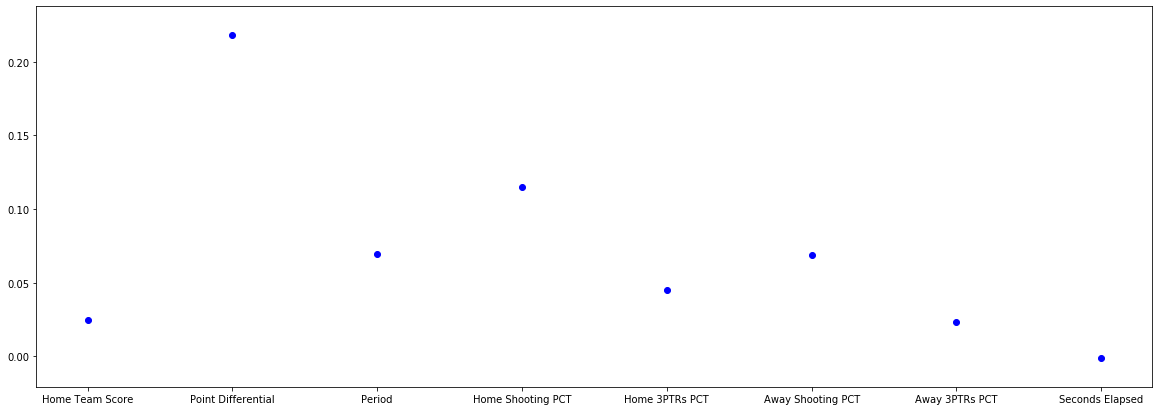

In [56]:
plt.figure(figsize=(20,7))
plt.scatter(cols,importance,c='b')

pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

clf = LogisticRegression(random_state = 42, max_iter=1000)
clf.fit(X_train,y_train)
classes = model.predict(X_test)
probs = model.predict_proba(X_test)
print(np.bincount(classes))

In [57]:
win_prob = clf.predict_proba(X_test)
win_prob

array([[0.46211371, 0.53788629],
       [0.46211371, 0.53788629],
       [0.46545503, 0.53454497],
       ...,
       [0.0253907 , 0.9746093 ],
       [0.02559789, 0.97440211],
       [0.02559789, 0.97440211]])

In [58]:
win_prob = pd.DataFrame(win_prob)

In [59]:
win_prob = win_prob[1]

In [60]:
win_prob

0        0.537886
1        0.537886
2        0.534545
3        0.534545
4        0.532316
           ...   
83447    0.950359
83448    0.950359
83449    0.974609
83450    0.974402
83451    0.974402
Name: 1, Length: 83452, dtype: float64

In [61]:
win_prob = clf.predict_proba(X_test)[:,1]

In [62]:
len(X_test)

83452

In [63]:
sub = X_test

In [64]:
X_test

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
2,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0
3,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0
4,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0
5,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0
6,0,0.0,1.0,0.000,0.000,0.000,0.000,59.0
...,...,...,...,...,...,...,...,...
85407,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0
85408,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0
85409,82,18.0,2.0,0.458,0.375,0.518,0.446,2378.0
85410,82,18.0,2.0,0.452,0.364,0.514,0.439,2384.0


In [65]:
X_test.loc[X_test['Period'] == 4]

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed
10146,78,0.0,4.0,0.500,0.407,0.500,0.396,2700.0
10147,78,0.0,4.0,0.500,0.407,0.500,0.396,2700.0
10148,78,0.0,4.0,0.500,0.407,0.500,0.396,2700.0
10149,78,0.0,4.0,0.500,0.407,0.500,0.396,2700.0
10150,80,2.0,4.0,0.500,0.407,0.503,0.396,2706.0
...,...,...,...,...,...,...,...,...
29428,80,-1.0,4.0,0.549,0.390,0.549,0.390,2978.0
29429,80,-1.0,4.0,0.549,0.390,0.549,0.390,2984.0
29430,82,1.0,4.0,0.552,0.390,0.552,0.390,2998.0
29431,82,1.0,4.0,0.548,0.381,0.548,0.381,3000.0


In [66]:
sub = pd.DataFrame(sub)

In [67]:
win_prob

array([0.53788629, 0.53788629, 0.53454497, ..., 0.9746093 , 0.97440211,
       0.97440211])

In [68]:
sub['WinProb'] = win_prob

In [69]:
sub['GameID'] = test_game_ids

In [70]:
sub['Outcome'] = y_test

In [71]:
sub['Play'] = play_description

In [72]:
sub

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,WinProb,GameID,Outcome,Play
2,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0,0.537886,18_11_10_2_01,1,"MISS 3PTR by SPRAGG,BAILEY"
3,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0,0.537886,18_11_10_2_01,1,"REBOUND DEF by ALLISON,ZACHARY"
4,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0,0.534545,18_11_10_2_01,1,"MISS 3PTR by BAK,CALVIN"
5,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0,0.534545,18_11_10_2_01,1,"REBOUND DEF by PALMER,NICK"
6,0,0.0,1.0,0.000,0.000,0.000,0.000,59.0,0.532316,18_11_10_2_01,1,"MISS 3PTR by MITCHELL,JAMES"
...,...,...,...,...,...,...,...,...,...,...,...,...
85407,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0,0.950359,19_02_22_4_27,1,"MISS 3PTR by STANLEY,SETH"
85408,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0,0.950359,19_02_22_4_27,1,"REBOUND DEF by LEE,MATT"
85409,82,18.0,2.0,0.458,0.375,0.518,0.446,2378.0,0.974609,19_02_22_4_27,1,"GOOD 3PTR by CARLETELLO,EMILY"
85410,82,18.0,2.0,0.452,0.364,0.514,0.439,2384.0,0.974402,19_02_22_4_27,1,"MISS 3PTR by CALAMESE,MICHAEL"


In [73]:
sub[sub['GameID'] == '19_02_22_4_27']

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,WinProb,GameID,Outcome,Play
84985,2,2.0,1.0,0.000,0.000,0.500,0.000,74.0,0.652990,19_02_22_4_27,0,"MISS 3PTR by COMAN,SEAN"
84986,2,2.0,1.0,0.000,0.000,0.500,0.000,74.0,0.652990,19_02_22_4_27,0,"REBOUND DEF by WARLICK,JORDAN"
84987,2,2.0,1.0,0.000,0.000,0.333,0.000,85.0,0.647569,19_02_22_4_27,0,"MISS 3PTR by BUESCHER,HUNTER"
84988,2,2.0,1.0,0.000,0.000,0.333,0.000,85.0,0.647569,19_02_22_4_27,0,"REBOUND DEF by STANLEY,SETH"
84989,2,2.0,1.0,0.000,0.000,0.250,0.000,107.0,0.640609,19_02_22_4_27,0,"MISS LAYUP by LINK,JACOB"
...,...,...,...,...,...,...,...,...,...,...,...,...
85407,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0,0.950359,19_02_22_4_27,1,"MISS 3PTR by STANLEY,SETH"
85408,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0,0.950359,19_02_22_4_27,1,"REBOUND DEF by LEE,MATT"
85409,82,18.0,2.0,0.458,0.375,0.518,0.446,2378.0,0.974609,19_02_22_4_27,1,"GOOD 3PTR by CARLETELLO,EMILY"
85410,82,18.0,2.0,0.452,0.364,0.514,0.439,2384.0,0.974402,19_02_22_4_27,1,"MISS 3PTR by CALAMESE,MICHAEL"


In [74]:
sub.describe()

,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,WinProb,Outcome
count,83452.000000,83452.000000,83452.000000,83452.000000,83452.000000,83452.000000,83452.000000,83452.000000,83452.000000
mean,1.878757,1.550748,0.463504,0.321540,0.472670,0.324832,1298.162668,0.536914,0.578716
std,11.672753,0.533366,0.112993,0.185939,0.080402,0.126739,690.568955,0.329960,0.493768
min,-50.000000,1.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000005,0.000000
25%,-4.000000,1.000000,0.405000,0.220000,0.435000,0.256000,702.000000,0.239535,0.000000
50%,2.000000,2.000000,0.467000,0.333000,0.478000,0.333000,1298.000000,0.566895,1.000000
75%,8.000000,2.000000,0.530000,0.412000,0.522000,0.400000,1893.000000,0.844761,1.000000
max,48.000000,4.000000,1.000000,1.000000,1.000000,1.000000,3000.000000,0.999975,1.000000


In [75]:
sub

,Home Team Score,Point Differential,Period,Home Shooting PCT,Home 3PTRs PCT,Away Shooting PCT,Away 3PTRs PCT,Seconds Elapsed,WinProb,GameID,Outcome,Play
2,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0,0.537886,18_11_10_2_01,1,"MISS 3PTR by SPRAGG,BAILEY"
3,0,0.0,1.0,0.000,0.000,0.000,0.000,39.0,0.537886,18_11_10_2_01,1,"REBOUND DEF by ALLISON,ZACHARY"
4,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0,0.534545,18_11_10_2_01,1,"MISS 3PTR by BAK,CALVIN"
5,0,0.0,1.0,0.000,0.000,0.000,0.000,51.0,0.534545,18_11_10_2_01,1,"REBOUND DEF by PALMER,NICK"
6,0,0.0,1.0,0.000,0.000,0.000,0.000,59.0,0.532316,18_11_10_2_01,1,"MISS 3PTR by MITCHELL,JAMES"
...,...,...,...,...,...,...,...,...,...,...,...,...
85407,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0,0.950359,19_02_22_4_27,1,"MISS 3PTR by STANLEY,SETH"
85408,79,15.0,2.0,0.458,0.375,0.514,0.436,2349.0,0.950359,19_02_22_4_27,1,"REBOUND DEF by LEE,MATT"
85409,82,18.0,2.0,0.458,0.375,0.518,0.446,2378.0,0.974609,19_02_22_4_27,1,"GOOD 3PTR by CARLETELLO,EMILY"
85410,82,18.0,2.0,0.452,0.364,0.514,0.439,2384.0,0.974402,19_02_22_4_27,1,"MISS 3PTR by CALAMESE,MICHAEL"


In [79]:
# sub = pd.read_csv('sample_submission.csv')
# sub['target'] = clf.predict_proba(X_test)[:,1]
# sub['game_id'] = X_test.iloc[:,0]
# sub['game_id'] = sub['game_id'].ffill()
# # for i in range(1, len(sub)):
# #     #print(sub['game_id'][i])
# #     if sub['game_id'][i] == 'NaN':
# #         print('hi')
# #         sub['game_id'][i] = sub['game_id'][i - 1]
# print(sub)
sub.to_csv('submission_no_record.csv',index=False)  

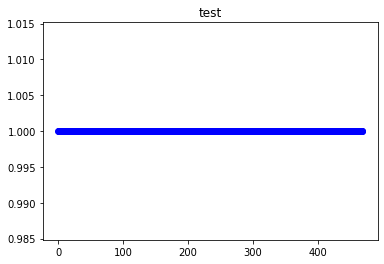

In [77]:
import matplotlib.pyplot as plt
import numpy as np


def plotGraph(y_test,y_pred,regressorName):
    if max(y_test) >= max(y_pred):
        my_range = int(max(y_test))
    else:
        my_range = int(max(y_pred))
    plt.scatter(range(len(y_test)), y_test, color='blue')
    #plt.scatter(range(len(y_pred)), y_pred, color='red')
    plt.title(regressorName)
    plt.show()
    return


plotGraph(y_test[0:470], y_pred[0:470], "test")

**Fitting Models to the Data**

In [78]:
Now that the data is prepped and ready, we can now apply 7 different models to our training data with the use of piplining: Logistic Regression, Perceptron, kNN, Naive Bayes, Decision Tree, Random Forest, and SVM.

SyntaxError: invalid syntax (<ipython-input-78-78ad692937f5>, line 1)

In [ ]:
pipeline_lr=Pipeline([('scalar1',StandardScaler()),
('pca1',PCA(n_components=2)),
('lr_classifier',LogisticRegression())])
pipeline_dt=Pipeline([('scalar2',StandardScaler()),
('pca2',PCA(n_components=2)),
('dt_classifier',DecisionTreeClassifier())])
pipeline_svm = Pipeline([('scalar3', StandardScaler()),
('pca3', PCA(n_components=2)),
('clf', svm.SVC())])
pipeline_knn=Pipeline([('scalar4',StandardScaler()),
('pca4',PCA(n_components=2)),
('knn_classifier',KNeighborsClassifier())])
pipeline_randomforest = Pipeline([('scalar5',StandardScaler()),
('pca5',PCA(n_components=2)),
('clf', RandomForestClassifier())])
pipeline_naivebayes = Pipeline([('scalar6',StandardScaler()),
('pca6',PCA(n_components=2)),
('clf', GaussianNB())])
pipeline_perceptron = Pipeline([('scalar7',StandardScaler()),
('pca7',PCA(n_components=2)),
('clf', Perceptron())])

In [ ]:
Using the Pipeline tool from the sklearn package, we can create a list of our models and evaluate their model scores, shown below:

In [ ]:
pipelines = [pipeline_lr, pipeline_dt, pipeline_svm, pipeline_knn, pipeline_randomforest, pipeline_naivebayes, pipeline_perceptron]
pipe_dict = {0: 'Logistic Regression', 1: 'Decision Tree',
2: 'Support Vector Machine',3:'K Nearest Neighbor',4:'Random Forest',5:'Naive Bayes',6:'Perceptron'}
for pipe in pipelines:
    pipe.fit(X_train, y_train)
for i, model in enumerate(pipelines):
    print("{} Test Accuracy:{}".format(pipe_dict[i],model.score(X_test,y_test)))

In [ ]:
From this printout, we can see that all of the models generally have about a 30-40% predictive score. However, with hyperparameter adjustment, we would like to try and improve these scores.

In [ ]:
**Hyperparameter Tuning**

In [ ]:
We then used grid search to try multiple hyperparameter tunings to see which one from the list gave the best results.

In [ ]:
Logistic Regression

In [ ]:
solvers = ['newton-cg', 'lbfgs', 'liblinear']
penalty = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]
# define grid search
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
gs = GridSearchCV(LogisticRegression(), param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
gs_result = gs.fit(X_train,y_train)
gs_result.score(X_test,y_test)
# summarize results
print("Best: %f using %s" % (gs_result.best_score_, gs_result.best_params_))

In [ ]:
Random Forest

In [ ]:
pipe = make_pipeline((RandomForestClassifier()))
rfc=RandomForestClassifier(random_state=1)
param_grid = { 
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
CV_rfc.fit(X_train, y_train)
CV_rfc.best_params_
print("Best: %f using %s" % (CV_rfc.best_score_, CV_rfc.best_params_))

In [ ]:
SVM

In [ ]:
kernel = ['poly', 'rbf', 'sigmoid']
C = [50, 10, 1.0, 0.1, 0.01]
gamma = ['scale']
# define grid search
grid = dict(kernel=kernel,C=C,gamma=gamma)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=1)
gs = GridSearchCV(svm.SVC(), param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
gs_result = gs.fit(X_train,y_train)
gs_result.score(X_test,y_test)
# summarize results
print("Best: %f using %s" % (gs_result.best_score_, gs_result.best_params_))

In [ ]:
Decision Tree

In [ ]:
n_estimators = [10, 100, 1000]
grid = dict({'max_leaf_nodes': list(range(2, 100)), 'min_samples_split': [2, 3, 4]})
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
grid_result = grid_search.fit(X_train,y_train)
grid_result.score(X_test,y_test)
# summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

In [ ]:
kNN

In [ ]:
grid_param={'n_neighbors':[3,5,7,11],'weights':['uniform','distance'],'metric':['euclidean','manhattan']}
gs=GridSearchCV(KNeighborsClassifier(),grid_param,verbose=1,cv=3,n_jobs=-1,)
gs_result=gs.fit(X_train,y_train)
gs_result.score(X_test,y_test)
print(gs_result.best_score_,'score')
print(gs_result.best_params_,'params')

In [ ]:
Perceptron

In [ ]:
mlp_gs = MLPClassifier(max_iter=1000)

gs = GridSearchCV(mlp_gs, param_grid= {
    'activation': ['tanh', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant','adaptive'],
}
)
gs = gs.fit(X_train,y_train)
gs.score(X_test,y_test)
print(gs.best_score_)
print(gs.best_estimator_)

In [ ]:
solver = ['newton-cg']
penalty = ['l2']
C = [100]
# define grid search
grid = dict(solver=solver,penalty=penalty,C=C)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
gs = GridSearchCV(LogisticRegression(), param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)
gs_result = gs.fit(X_test,y_test)
gs_result.score(X_test,y_test)
# summarize results
print("Best: %f using %s" % (gs_result.best_score_, gs_result.best_params_))